# 04 - Forecast Model

## Objective
Build and evaluate a Prophet demand forecasting model for Club Piscine franchise inventory planning.

## Model: Facebook Prophet + Weather Regressors
Chosen for:
- Native trend + seasonality decomposition
- Easy external regressors (weather, holidays)
- Interpretable output (franchise-friendly)
- Confidence intervals out of the box

## Inputs
| Variable | Source | Role |
|---|---|---|
| `week_ending` | modeling_dataset.csv | Date index (ds) |
| `sales` | Montant de la ligne (weekly sum) | Target (y) |
| `avg_temp` | Open-Meteo | Weather regressor |
| `bad_weather_days` | Open-Meteo | Weather regressor |
| `snow_days` | Open-Meteo | Weather regressor |
| `has_holiday` | python-holidays (QC/ON) | Calendar regressor |

## Outputs
| File | Description |
|---|---|
| `forecast_output.csv` | 4–8 week forward forecasts per store × division |
| `model_accuracy.csv` | MAPE + MAE per group |
| `reports/figures/forecast_*.png` | One plot per group |

## Forecast Definition
- **Target:** Weekly Sales Volume (CAD)
- **Granularity:** Week × Store × Division Code
- **Horizon:** 4–8 weeks ahead (configurable)

## ⚠️ Data Limitation
Only 14 weeks of history (June–Sept 2025). This is a prototype.
`yearly_seasonality=False` — cannot estimate annual cycle from 14 weeks.
---

---
## Cell 1: Imports and Configuration
---

In [7]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
import logging
from pathlib import Path

warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────
# MODEL CONFIGURATION
# ─────────────────────────────────────────────
FORECAST_HORIZON = 4 #8     # Weeks to predict ahead
MIN_HISTORY      = 8 #10    # Min weeks required (lowered for 14-week dataset)
CONFIDENCE_LEVEL = 0.95  # CI width

# Prophet regressors (weather + calendar)
# Using raw values — with only 14 weeks, deviation z-scores have poor baselines
PROPHET_REGRESSORS = [
    'avg_temp',          # Primary demand driver for pool/spa
    'bad_weather_days',  # Bad weather suppresses store visits
    'snow_days',         # Snow-specific (relevant for QC stores)
    'has_holiday',       # Holiday week flag
]

print('✅ Configuration:')
print(f'   Forecast horizon  : {FORECAST_HORIZON} weeks')
print(f'   Min history       : {MIN_HISTORY} weeks')
print(f'   Confidence        : {int(CONFIDENCE_LEVEL*100)}%')
print(f'   Regressors        : {PROPHET_REGRESSORS}')
print(f'   yearly_seasonality: False (only 14 weeks — cannot estimate)')
print(f'   weekly_seasonality: False (weekly data, not sub-daily)')

✅ Configuration:
   Forecast horizon  : 4 weeks
   Min history       : 8 weeks
   Confidence        : 95%
   Regressors        : ['avg_temp', 'bad_weather_days', 'snow_days', 'has_holiday']
   yearly_seasonality: False (only 14 weeks — cannot estimate)
   weekly_seasonality: False (weekly data, not sub-daily)


---
## Cell 2: Load Modeling Dataset

**Input:** `modeling_dataset.csv` (from 03_feature_engineering.ipynb)
**Schema:** week_ending | store_code | city | division_code | sales | weather + features
---

In [8]:
df = pd.read_csv(DATA_PROCESSED / 'modeling_dataset.csv')
df['week_ending'] = pd.to_datetime(df['week_ending'])
df = df.sort_values(['store_code','division_code','week_ending']).reset_index(drop=True)

GROUP_COLS = ['store_code','city','division_code']

print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Date range: {df["week_ending"].min().date()} → {df["week_ending"].max().date()}')
print(f'Stores: {df["store_code"].unique()}')
print(f'Division codes: {sorted(df["division_code"].unique())}')
print(f'Total groups: {df.groupby(GROUP_COLS).ngroups}')

Dataset: 1,333 rows × 53 cols
Date range: 2025-06-08 → 2025-09-14
Stores: ['CP08' 'CP202' 'CP37' 'CP44' 'CP48']
Division codes: ['AM', 'AP', 'AS', 'AZ', 'BQ', 'CA', 'CC', 'CH', 'CR', 'DI', 'FI', 'GA', 'HT', 'IN', 'INM', 'LI', 'LO', 'ME', 'MK', 'PA', 'PC', 'PI', 'SA', 'SE', 'SP', 'TO']
Total groups: 111


---
## Cell 3: Prophet Model Builder

Reusable function that handles one Store × Division time series:
1. Train / test split (last N weeks held out for evaluation)
2. Fit Prophet on train set with weather regressors → evaluate on test
3. Refit on full data → generate true forward forecast
---

In [9]:
def build_prophet_forecast(group_df, group_label, forecast_horizon,
                            prophet_regressors, confidence):
    """
    Fit Prophet for one Store × Division Code time series.

    Parameters
    ----------
    group_df           : DataFrame with week_ending, sales, + regressor columns
    group_label        : str — readable name for logging/plotting
    forecast_horizon   : int — weeks to predict ahead
    prophet_regressors : list[str] — external regressor column names
    confidence         : float — confidence interval width (e.g. 0.95)

    Returns
    -------
    metrics       : dict — MAPE, MAE, train/test week counts
    forecast_rows : list[dict] — forward forecast rows
    eval_forecast : DataFrame — Prophet forecast on test period (for plotting)
    test, train   : DataFrames — held-out and training sets
    eval_preds    : array — point predictions on test period
    """
    ts = (
        group_df.sort_values('week_ending')
                .rename(columns={'week_ending':'ds','sales':'y'})
                .copy()
    )
    ts['y'] = ts['y'].clip(lower=0)  # No negative sales

    available_regs = [r for r in prophet_regressors if r in ts.columns]

    # Train / Test split
    train = ts.iloc[:-forecast_horizon].copy()
    test  = ts.iloc[-forecast_horizon:].copy()

    # ── Fit on train, evaluate on test ──────────────────────────────
    eval_model = Prophet(
        yearly_seasonality  = False,   # Only 14 weeks — not enough to estimate
        weekly_seasonality  = False,   # Weekly data, no sub-daily patterns
        daily_seasonality   = False,
        interval_width      = confidence
    )
    for reg in available_regs:
        eval_model.add_regressor(reg, standardize=True)

    eval_model.fit(train[['ds','y'] + available_regs])

    eval_future = eval_model.make_future_dataframe(periods=forecast_horizon, freq='W')
    eval_future = eval_future.merge(ts[['ds'] + available_regs], on='ds', how='left')
    for reg in available_regs:
        eval_future[reg] = eval_future[reg].fillna(eval_future[reg].median())

    eval_forecast = eval_model.predict(eval_future)
    eval_preds    = eval_forecast.tail(forecast_horizon)['yhat'].values
    actuals       = test['y'].values

    mape = mean_absolute_percentage_error(actuals, eval_preds)
    mae  = mean_absolute_error(actuals, eval_preds)

    metrics = {
        'MAPE':        round(mape, 4),
        'MAE':         round(mae, 2),
        'Train_Weeks': len(train),
        'Test_Weeks':  forecast_horizon,
        'Regressors':  ', '.join(available_regs)
    }

    # ── Refit on full data → true forward forecast ───────────────────
    full_model = Prophet(
        yearly_seasonality = False,
        weekly_seasonality = False,
        daily_seasonality  = False,
        interval_width     = confidence
    )
    for reg in available_regs:
        full_model.add_regressor(reg, standardize=True)

    full_model.fit(ts[['ds','y'] + available_regs])

    full_future = full_model.make_future_dataframe(periods=forecast_horizon, freq='W')
    full_future = full_future.merge(ts[['ds'] + available_regs], on='ds', how='left')
    for reg in available_regs:
        full_future[reg] = full_future[reg].fillna(full_future[reg].median())

    full_forecast = full_model.predict(full_future)
    forward       = full_forecast.tail(forecast_horizon)

    forecast_rows = [
        {
            'Week':           row['ds'],
            'Forecast_Sales': round(max(0, row['yhat']), 2),
            'Lower_CI':       round(max(0, row['yhat_lower']), 2),
            'Upper_CI':       round(max(0, row['yhat_upper']), 2),
        }
        for _, row in forward.iterrows()
    ]

    return metrics, forecast_rows, eval_forecast, test, train, eval_preds


print('✅ build_prophet_forecast() defined')

✅ build_prophet_forecast() defined


---
## Cell 4: Run Forecasting Loop

Iterates every **Store × Division Code** group.
Skips groups with < MIN_HISTORY weeks.
Saves one evaluation plot per group.
---

In [10]:
results_list  = []
forecast_list = []
skipped       = []

groups = list(df.groupby(GROUP_COLS))
print(f'Total groups: {len(groups)}')
print(f'Forecast horizon: {FORECAST_HORIZON} weeks')
print('─' * 75)

for keys, group in groups:
    store, city, div = keys
    label    = f'{store} ({city}) – {div}'
    key_dict = {'store_code': store, 'city': city, 'division_code': div}

    if len(group) < MIN_HISTORY + FORECAST_HORIZON:
        print(f'  ⚠ SKIP  {label:<45} ({len(group)} weeks only)')
        skipped.append(label)
        continue

    try:
        metrics, forecast_rows, eval_forecast, test, train, eval_preds = build_prophet_forecast(
            group_df           = group,
            group_label        = label,
            forecast_horizon   = FORECAST_HORIZON,
            prophet_regressors = PROPHET_REGRESSORS,
            confidence         = CONFIDENCE_LEVEL
        )

        results_list.append({**key_dict, **metrics})
        for row in forecast_rows:
            forecast_list.append({**key_dict, **row})

        print(f'  ✓ {label:<45}  MAPE={metrics["MAPE"]:.1%}  MAE={metrics["MAE"]:,.0f}')

        # Plot
        fig, ax = plt.subplots(figsize=(13, 5))
        tr = train.rename(columns={'ds':'week_ending','y':'sales'})
        te = test.rename(columns={'ds':'week_ending','y':'sales'})

        ax.plot(tr['week_ending'], tr['sales'], label='Train', color='steelblue', linewidth=1.5)
        ax.plot(te['week_ending'], te['sales'], label='Actual', color='green', linewidth=2)
        ax.plot(te['week_ending'], eval_preds,  label='Forecast', color='orange',
                linestyle='--', linewidth=2)
        tail = eval_forecast.tail(FORECAST_HORIZON)
        ax.fill_between(pd.to_datetime(tail['ds']),
                        tail['yhat_lower'], tail['yhat_upper'],
                        alpha=0.2, color='orange', label=f'{int(CONFIDENCE_LEVEL*100)}% CI')
        ax.set_title(f'{label} | MAPE: {metrics["MAPE"]:.1%} | MAE: {metrics["MAE"]:,.0f}',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Week')
        ax.set_ylabel('Weekly Sales ($)')
        ax.legend(loc='upper left', fontsize=9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        plt.tight_layout()
        fname = label.replace(' ','_').replace('(','').replace(')','').replace('/','').replace('–','-')
        plt.savefig(FIGURES / f'forecast_{fname}.png', dpi=150, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f'  ✗ ERROR {label:<45} — {e}')

print('─' * 75)
print(f'✅ Done: {len(results_list)} groups modelled, {len(skipped)} skipped')

Total groups: 111
Forecast horizon: 4 weeks
───────────────────────────────────────────────────────────────────────────
  ⚠ SKIP  CP08 (Longueuil) – AM                         (11 weeks only)


17:19:11 - cmdstanpy - INFO - Chain [1] start processing
17:19:11 - cmdstanpy - INFO - Chain [1] done processing
17:19:11 - cmdstanpy - INFO - Chain [1] start processing
17:19:11 - cmdstanpy - INFO - Chain [1] done processing


  ✓ CP08 (Longueuil) – AP                          MAPE=76.8%  MAE=6,653


17:19:12 - cmdstanpy - INFO - Chain [1] start processing
17:19:12 - cmdstanpy - INFO - Chain [1] done processing
17:19:12 - cmdstanpy - INFO - Chain [1] start processing
17:19:12 - cmdstanpy - INFO - Chain [1] done processing
17:19:12 - cmdstanpy - INFO - Chain [1] start processing
17:19:12 - cmdstanpy - INFO - Chain [1] done processing


  ✓ CP08 (Longueuil) – AS                          MAPE=477.0%  MAE=3,817


...

  ✓ CP48 (Beloeil) – PI                            MAPE=68294612664549335040.0%  MAE=2,500
  ⚠ SKIP  CP48 (Beloeil) – SA                           (1 weeks only)


17:19:37 - cmdstanpy - INFO - Chain [1] done processing
17:19:37 - cmdstanpy - INFO - Chain [1] start processing
17:19:37 - cmdstanpy - INFO - Chain [1] done processing


  ✓ CP48 (Beloeil) – SE                            MAPE=118.9%  MAE=204


17:19:38 - cmdstanpy - INFO - Chain [1] start processing
17:19:38 - cmdstanpy - INFO - Chain [1] done processing
17:19:38 - cmdstanpy - INFO - Chain [1] start processing
17:19:38 - cmdstanpy - INFO - Chain [1] done processing


  ⚠ SKIP  CP48 (Beloeil) – SP                           (11 weeks only)
  ✓ CP48 (Beloeil) – TO                            MAPE=282.4%  MAE=1,343
───────────────────────────────────────────────────────────────────────────
✅ Done: 79 groups modelled, 32 skipped


---
## Cell 5: Model Accuracy Summary
---

MODEL ACCURACY SUMMARY
Groups evaluated : 79
Forecast horizon : 4 weeks
Overall MAPE     : 39835419001025945600.0%  (median: 621.1%)
Overall MAE      : 5,998

By group:
store_code        city division_code         MAPE      MAE  Train_Weeks  Test_Weeks                                         Regressors
      CP48     Beloeil            AP 4.314000e-01  2515.74           11           4 avg_temp, bad_weather_days, snow_days, has_holiday
      CP44 St-Constant            IN 5.266000e-01   897.94            9           4 avg_temp, bad_weather_days, snow_days, has_holiday
      CP44 St-Constant            PC 6.114000e-01  2906.25           11           4 avg_temp, bad_weather_days, snow_days, has_holiday
      CP08   Longueuil            PC 6.295000e-01  4025.76           11           4 avg_temp, bad_weather_days, snow_days, has_holiday
      CP44 St-Constant            AZ 6.311000e-01   481.92           11           4 avg_temp, bad_weather_days, snow_days, has_holiday
      CP48     Beloei

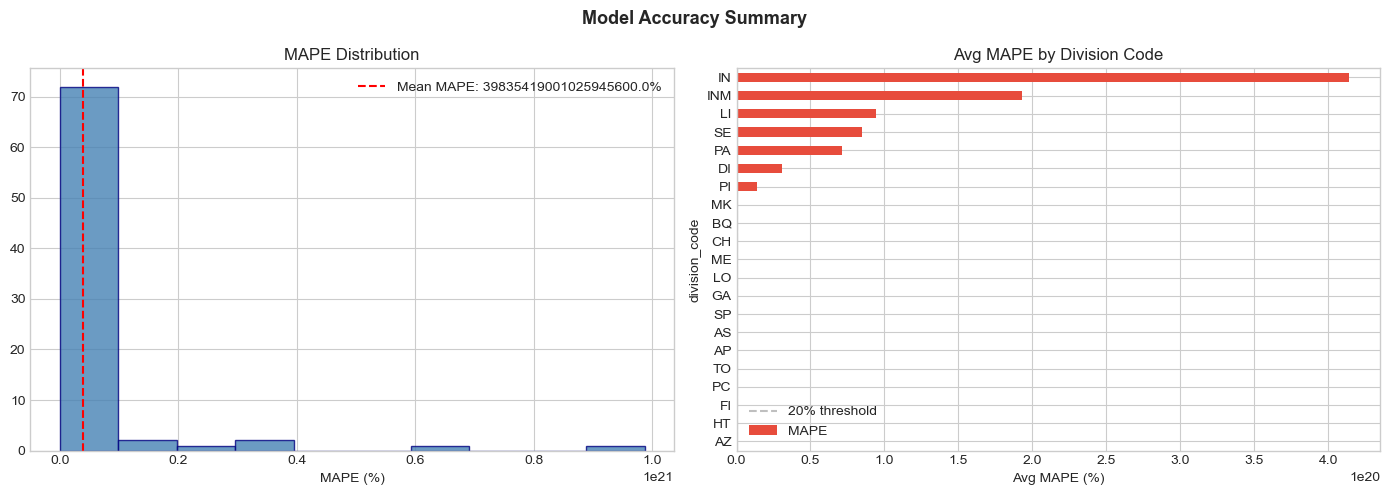

✅ Saved: model_accuracy_summary.png


In [11]:
accuracy_df = pd.DataFrame(results_list)

print('='*70)
print('MODEL ACCURACY SUMMARY')
print('='*70)
print(f'Groups evaluated : {len(accuracy_df)}')
print(f'Forecast horizon : {FORECAST_HORIZON} weeks')
print(f'Overall MAPE     : {accuracy_df["MAPE"].mean():.1%}  (median: {accuracy_df["MAPE"].median():.1%})')
print(f'Overall MAE      : {accuracy_df["MAE"].mean():,.0f}')
print()
print('By group:')
print(accuracy_df.sort_values('MAPE').to_string(index=False))

# Accuracy viz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(accuracy_df['MAPE']*100, bins=10, color='steelblue', edgecolor='navy', alpha=0.8)
axes[0].axvline(accuracy_df['MAPE'].mean()*100, color='red', linestyle='--',
                label=f'Mean MAPE: {accuracy_df["MAPE"].mean():.1%}')
axes[0].set_xlabel('MAPE (%)')
axes[0].set_title('MAPE Distribution')
axes[0].legend()

if 'division_code' in accuracy_df.columns:
    div_mape = accuracy_df.groupby('division_code')['MAPE'].mean().sort_values()
    colors   = ['#2ecc71' if v<0.20 else '#f39c12' if v<0.35 else '#e74c3c'
                for v in div_mape]
    (div_mape*100).plot(kind='barh', ax=axes[1], color=colors)
    axes[1].set_xlabel('Avg MAPE (%)')
    axes[1].set_title('Avg MAPE by Division Code')
    axes[1].axvline(20, color='grey', linestyle='--', alpha=0.5, label='20% threshold')
    axes[1].legend()

plt.suptitle('Model Accuracy Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'model_accuracy_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model_accuracy_summary.png')

---
## Cell 6: Forecast Output Table

Primary deliverable for Power BI integration.
Schema: store_code | city | division_code | Week | Forecast_Sales | Lower_CI | Upper_CI
---

In [12]:
forecast_df = pd.DataFrame(forecast_list)
forecast_df['Week'] = pd.to_datetime(forecast_df['Week'])
forecast_df = forecast_df.sort_values(GROUP_COLS + ['Week']).reset_index(drop=True)

print(f'Forecast output: {len(forecast_df):,} rows')
print(f'Weeks ahead: {FORECAST_HORIZON}')
print(f'Window: {forecast_df["Week"].min().date()} → {forecast_df["Week"].max().date()}')
print()
forecast_df.head(20)

Forecast output: 316 rows
Weeks ahead: 4
Window: 2025-08-31 → 2025-10-12



,store_code,city,division_code,Week,Forecast_Sales,Lower_CI,Upper_CI
0,CP08,Longueuil,AP,2025-09-21,1993.62,0.00,8558.76
1,CP08,Longueuil,AP,2025-09-28,0.00,0.00,4193.13
2,CP08,Longueuil,AP,2025-10-05,0.00,0.00,0.00
3,CP08,Longueuil,AP,2025-10-12,0.00,0.00,0.00
4,CP08,Longueuil,AS,2025-09-21,0.00,0.00,2020.58
5,CP08,Longueuil,AS,2025-09-28,0.00,0.00,1653.85
6,CP08,Longueuil,AS,2025-10-05,0.00,0.00,1148.57
7,CP08,Longueuil,AS,2025-10-12,0.00,0.00,735.50
8,CP08,Longueuil,AZ,2025-09-21,950.55,106.60,1774.42
9,CP08,Longueuil,AZ,2025-09-28,1062.28,251.97,1938.33


In [13]:
# Aggregated view: by store (useful for Power BI executive summary)
forecast_store = (
    forecast_df.groupby(['store_code','city','Week'])
               .agg(Forecast_Sales=('Forecast_Sales','sum'),
                    Lower_CI=('Lower_CI','sum'),
                    Upper_CI=('Upper_CI','sum'))
               .reset_index()
)
print('Store-level aggregate:')
print(forecast_store.head(20).to_string(index=False))

Store-level aggregate:
store_code      city       Week  Forecast_Sales  Lower_CI  Upper_CI
      CP08 Longueuil 2025-09-07         6604.48      0.00  21328.95
      CP08 Longueuil 2025-09-14         9727.11      0.00  38331.39
      CP08 Longueuil 2025-09-21        21337.43    804.13  81399.33
      CP08 Longueuil 2025-09-28        12184.51    254.50  66584.44
      CP08 Longueuil 2025-10-05         3534.35    349.24  34501.94
      CP08 Longueuil 2025-10-12         1293.99    436.67  18603.68
     CP202    Nepean 2025-08-31        12928.72      0.00  47097.20
     CP202    Nepean 2025-09-07        15203.73      0.00  63898.78
     CP202    Nepean 2025-09-14        12854.04      0.00  66487.91
     CP202    Nepean 2025-09-21        23030.76    154.53 104197.29
     CP202    Nepean 2025-09-28        11426.17    130.68  56391.77
     CP202    Nepean 2025-10-05         5455.02    115.65  36386.87
     CP202    Nepean 2025-10-12         1364.73    127.55  23571.29
      CP37  Gatineau 2025

---
## Cell 7: Inventory Gap Analysis (Prototype)

Compare forecast demand vs current inventory snapshot to flag potential stock gaps.
This is the key insight for franchise planning in Power BI.
---

In [ ]:
# Load inventory snapshot
inventaire = pd.read_excel(PROJECT_ROOT / 'data' / 'raw' / 'Exemple_Table_Inventaire.xlsx')

# Aggregate available quantity by store + division
# Map Location Code → store_code (strip demo/warehouse suffixes)
inventaire['store_code'] = inventaire['Location Code'].str.extract(r'(CP\d+)', expand=False)
inv_summary = (
    inventaire.groupby(['store_code','Division Code'])
              .agg(qty_available=('Quantity Available','sum'),
                   inventory_value=('Inventory Value','sum'))
              .reset_index()
              .rename(columns={'Division Code':'division_code'})
)

# Total forecasted demand over horizon per store × division
forecast_demand = (
    forecast_df.groupby(['store_code','division_code'])['Forecast_Sales']
               .sum()
               .reset_index()
               .rename(columns={'Forecast_Sales':'forecast_demand_total'})
)

# Join
gap = forecast_demand.merge(inv_summary, on=['store_code','division_code'], how='left')
gap['inventory_value']   = gap['inventory_value'].fillna(0)
gap['qty_available']     = gap['qty_available'].fillna(0)
gap['demand_vs_stock']   = gap['forecast_demand_total'] - gap['inventory_value']
gap['gap_flag']          = (gap['demand_vs_stock'] > 0).map({True:'⚠️ Potential gap', False:'✅ OK'})

print('Inventory Gap Analysis:')
print('(Forecast demand vs current inventory value over next', FORECAST_HORIZON, 'weeks)')
print(gap.sort_values('demand_vs_stock', ascending=False).to_string(index=False))

Inventory Gap Analysis:
(Forecast demand vs current inventory value over next 4 weeks)
store_code division_code  forecast_demand_total  qty_available  inventory_value  demand_vs_stock         gap_flag
      CP48            IN                1107.31            0.0             0.00          1107.31 ⚠️ Potential gap
     CP202            LI                 762.24           -3.0             0.00           762.24 ⚠️ Potential gap
      CP08            LI                 537.22            0.0             0.00           537.22 ⚠️ Potential gap
      CP48            LI                 310.52            0.0             0.00           310.52 ⚠️ Potential gap
      CP48            SE                 218.85            0.0             0.00           218.85 ⚠️ Potential gap
      CP08            SE                 183.67            0.0             0.00           183.67 ⚠️ Potential gap
     CP202            DI                 147.77          -73.0             0.00           147.77 ⚠️ Potential gap
 

---
## Cell 8: Save Outputs
---

In [15]:
accuracy_df.to_csv(DATA_PROCESSED / 'model_accuracy.csv', index=False)
forecast_df.to_csv(DATA_PROCESSED / 'forecast_output.csv', index=False)
forecast_store.to_csv(DATA_PROCESSED / 'forecast_output_by_store.csv', index=False)
gap.to_csv(DATA_PROCESSED / 'inventory_gap_analysis.csv', index=False)

print(f'✅ model_accuracy.csv             ({len(accuracy_df)} groups)')
print(f'✅ forecast_output.csv            ({len(forecast_df):,} rows)')
print(f'✅ forecast_output_by_store.csv   ({len(forecast_store):,} rows)')
print(f'✅ inventory_gap_analysis.csv     ({len(gap)} rows)')
print(f'✅ Plots saved to reports/figures/forecast_*.png')
print(f"""
Summary:
  Model          : Prophet + weather regressors
  Stores         : CP08 (Longueuil), CP37 (Gatineau),
                   CP44 (St-Constant), CP48 (Beloeil), CP202 (Nepean)
  Division codes : {sorted(df['division_code'].unique())}
  Horizon        : {FORECAST_HORIZON} weeks
  Groups modelled: {len(accuracy_df)}
  Mean MAPE      : {accuracy_df['MAPE'].mean():.1%}

⚠️  Prototype built on 14 weeks of data.
""")

✅ model_accuracy.csv             (79 groups)
✅ forecast_output.csv            (316 rows)
✅ forecast_output_by_store.csv   (32 rows)
✅ inventory_gap_analysis.csv     (79 rows)
✅ Plots saved to reports/figures/forecast_*.png

Summary:
  Model          : Prophet + weather regressors
  Stores         : CP08 (Longueuil), CP37 (Gatineau),
                   CP44 (St-Constant), CP48 (Beloeil), CP202 (Nepean)
  Division codes : ['AM', 'AP', 'AS', 'AZ', 'BQ', 'CA', 'CC', 'CH', 'CR', 'DI', 'FI', 'GA', 'HT', 'IN', 'INM', 'LI', 'LO', 'ME', 'MK', 'PA', 'PC', 'PI', 'SA', 'SE', 'SP', 'TO']
  Horizon        : 4 weeks
  Groups modelled: 79
  Mean MAPE      : 39835419001025945600.0%

⚠️  Prototype built on 14 weeks of data.

